## **Problem Statement**

* **Customer Behaviour and it’s prediction lies at the core of every Business Model. From Stock Exchange, e-Commerce and Automobile to even Presidential Elections,predictions serve a great purpose. Most of these predictions are based on the data available about a person’s activity either online or in-person.**

* **Recommendation Engines are the much needed manifestations of the desired Predictability of User Activity. Recommendation Engines move one step further and not only give information but put forth strategies to further increase users interaction with the platform.**


* **In today’s world OTT platform and Streaming Services have taken up a big chunk in the Retail and Entertainment industry.Organizations like Netflix, Amazon etc.analyse User Activity Pattern’s and suggest products that better suit the user needs and choices.**

* **For the purpose of this Project we will be creating one such Recommendation Engine from the ground-up, where every single user, based on there area of interest and ratings, would be recommended a list of movies that are best suited for them.**

## **Dataset Information**

1. **ID** – Contains the separate keys for
customer and movies.
2. **Rating** – A section contains the user
ratings for all the movies.
3. **Genre** – Highlights the category of the
movie.
4. **Movie Name** – Name of the movie with
respect to the movie id.

## **Objective**

1. Find out the list of most popular and liked genre
2. Create Model that finds the best suited Movie for one
user in every genre.
3. Find what Genre Movies have received the best and
worst ratings based on User Rating.

In [1]:
# Importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Connecting through google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#load Dataset
netflix_dataset = pd.read_csv('/content/drive/MyDrive/Netflix Dataset/combined_data_1.txt',header=None,usecols=[0,1],names=['CustID','Ratings'])

In [4]:
netflix_dataset.head()

,CustID,Ratings
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [5]:
#Checking info
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   CustID   object 
 1   Ratings  float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [6]:
#Rows and columns
netflix_dataset.shape

(24058263, 2)

In [7]:
netflix_dataset[netflix_dataset['CustID'].str.contains(':')]
netflix_dataset

,CustID,Ratings
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [8]:
movie_count = netflix_dataset[netflix_dataset['CustID'].str.contains(':')].count()[0]
movie_count

4499

In [9]:
movie_count

4499

In [10]:
netflix_dataset.isnull().sum()

,0
CustID,0
Ratings,4499


In [11]:
movie_count = netflix_dataset.isnull().sum()
movie_count = movie_count['Ratings']
movie_count

4499

In [12]:
cust_count = netflix_dataset['CustID'].unique()
cust_count

array(['1:', '1488844', '822109', ..., '72311', '4499:', '594210'],
      dtype=object)

In [13]:
cust_count = netflix_dataset['CustID'].nunique()
cust_count

475257

In [14]:
cust_count = cust_count - movie_count
cust_count

470758

In [15]:
rating_count = len(netflix_dataset) - movie_count
rating_count

24053764

In [16]:
stars = netflix_dataset.groupby('Ratings')['Ratings'].agg(['count'])
stars

,count
Ratings,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [17]:
plt.style.use('dark_background')

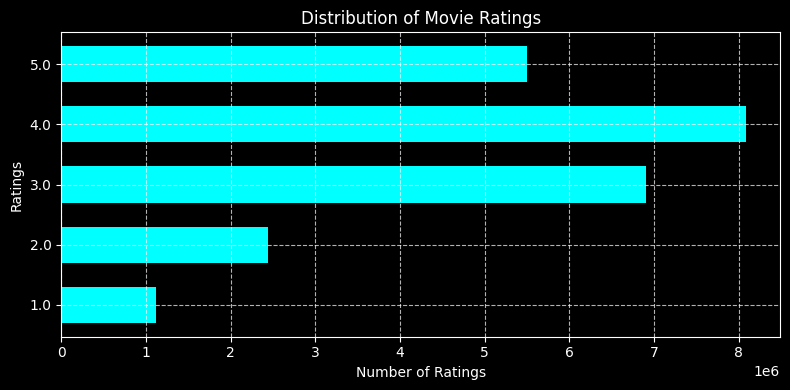

In [18]:
rating_count = netflix_dataset['Ratings'].value_counts().sort_index()

plt.figure(figsize=(8,4))

plt.barh(rating_count.index.astype(str),rating_count.values,height=0.6,color='cyan')
plt.ylabel('Ratings')
plt.xlabel('Number of Ratings')
plt.title('Distribution of Movie Ratings')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
movie_id = None
movie_np = []

for i in netflix_dataset['CustID']:
  if ":" in i:
    movie_id = int(i.replace(':',''))
  movie_np.append(movie_id)

In [20]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [21]:
netflix_dataset

,CustID,Ratings
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [22]:
netflix_dataset['Movie_ID'] = movie_np
netflix_dataset

,CustID,Ratings,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [23]:
netflix_dataset = netflix_dataset[netflix_dataset['Ratings'].notna()]
netflix_dataset

,CustID,Ratings,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [24]:
netflix_dataset['Movie_ID'].count()

24053764

In [25]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CustID    object 
 1   Ratings   float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [26]:
netflix_dataset['CustID'] = netflix_dataset['CustID'].astype(int)

In [27]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CustID    int64  
 1   Ratings   float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [28]:
dataset_movie_summary = netflix_dataset.groupby('Movie_ID')['Ratings'].agg(['count'])
dataset_movie_summary

,count
Movie_ID,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [29]:
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [30]:
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2699)

In [31]:
len(drop_movie_list)

2699

In [32]:
dataset_cust_summary = netflix_dataset.groupby('CustID')['Ratings'].agg(['count'])
dataset_cust_summary

,count
CustID,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [33]:
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [34]:
drop_cust_list = dataset_cust_summary[dataset_cust_summary['count'] < cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='CustID', length=282042)

In [35]:
len(drop_cust_list)

282042

In [36]:
#Remove the movie that didn't meet the benchmark (less rated movies)
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_ID'].isin(drop_movie_list)]

In [37]:
#Remove the CustID that didn't meet the benchmark (less rated movies)
netflix_dataset = netflix_dataset[~netflix_dataset['CustID'].isin(drop_cust_list)]
netflix_dataset

,CustID,Ratings,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


**We are keelping only those rows which are not in drop_cust_list**

## **Model Building**

In [38]:
# Load the second dataset for movie name as with the previous dataset we only have movie id

movie_title = pd.read_csv('/content/drive/MyDrive/Netflix Dataset/movie_titles.csv',encoding = 'ISO-8859-1',header=None,usecols=[0,1,2],names=['MovieID','Year','Name'])

In [39]:
movie_title

,MovieID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [40]:
!pip install numpy==1.23.5

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [41]:
!pip install scikit-surprise

In [42]:
pip install "numpy<2"

In [43]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [44]:
reader = Reader()

In [45]:
data = Dataset.load_from_df(netflix_dataset[['CustID','Movie_ID','Ratings']][:100000],reader)
data

In [46]:
model = SVD()
cross_validate(model,data,measures = ['RMSE'],cv = 3,verbose = True)

Evaluating RMSE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0168  1.0156  1.0264  1.0196  0.0048  
Fit time          0.93    0.87    0.86    0.89    0.03    
Test time         0.34    0.29    0.14    0.26    0.08    


{'test_rmse': array([1.01683775, 1.01556769, 1.02639966]),
 'fit_time': (0.926891565322876, 0.8746218681335449, 0.8641932010650635),
 'test_time': (0.34080076217651367, 0.29358887672424316, 0.14279913902282715)}

In [48]:
user_rating = netflix_dataset[netflix_dataset['CustID'] == 1331154]

In [49]:
user_rating

,CustID,Ratings,Movie_ID
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [50]:
actual_rating = user_rating['Ratings']
actual_rating

,Ratings
697,4.0
5178,4.0
31460,3.0
92840,4.0
224761,3.0
...,...
23439584,4.0
23546489,2.0
23649431,4.0
23844441,3.0
